In [7]:
import pandas as pd
import numpy as np

Ue = 50e-3 # peak voltage

def calcBode(df):
    df['A'] = 20 * np.log10(df['Ua'] / Ue)
    df['phi'] = 360*df['f']*df['DeltaT']
    return df

df_I = calcBode(pd.read_csv("./data/BodeI.csv"))
df_NI = calcBode(pd.read_csv("./data/BodeNI.csv"))

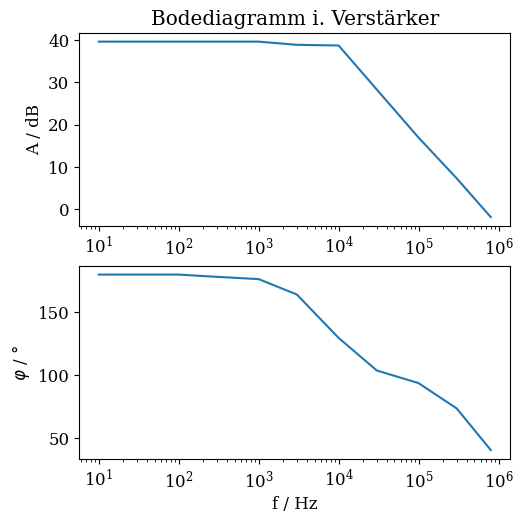

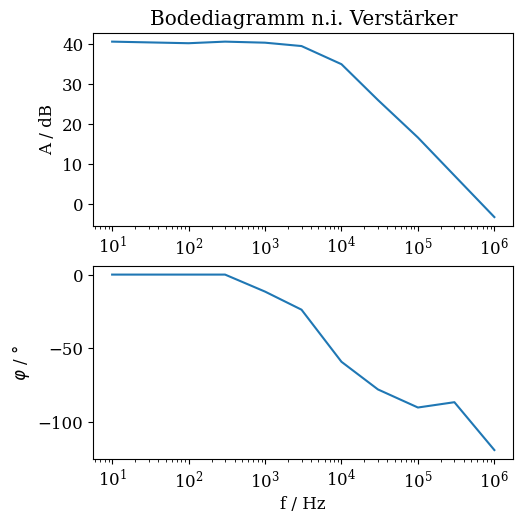

In [8]:
import matplotlib
from matplotlib import pyplot as plt

cm = 1/2.54

font = {'family' : 'serif',
        'weight' : 'normal',
        'size' : 12}
matplotlib.rc('font', **font)

def plot_bode(df, title="Bodediagramm"):
    fig, (ax_abs, ax_arg) = plt.subplots(nrows=2, ncols=1, figsize=(13*cm, 13*cm), constrained_layout=True)
    ax_abs.set_title(title)
    ax_abs.set_ylabel("A / dB")
    ax_abs.set_xscale('log')
    ax_abs.plot(df['f'], df['A'])

    ax_arg.set_xscale('log')
    ax_arg.set_xlabel("f / Hz")
    ax_arg.set_ylabel("$\\varphi$ / $\\degree$")
    ax_arg.plot(df['f'], df['phi'])

    return fig

fig_I = plot_bode(df_I, title="Bodediagramm i. Verstärker")
fig_I.savefig("./latex/images/bode_I.png")

fig_NI = plot_bode(df_NI, title="Bodediagramm n.i. Verstärker")
fig_NI.savefig("./latex/images/bode_NI.png")

In [9]:
fmt = {
    'f': '{:.0e}',
    'Ua': '{:.2f}',
    'DeltaT': '{:.2e}',
	'phi': '{:.2f}',
	'A': '{:.2f}',
}
latex_I = df_I.style.format(fmt).hide().to_latex()
latex_NI = df_NI.style.format(fmt).hide().to_latex()
with open("./latex/images/bode_tab_I.tex", "w") as f:
    f.write(latex_I)
with open("./latex/images/bode_tab_NI.tex", "w") as f:
    f.write(latex_NI)